# Study of the effect of slit distance on slit diffraction
awojdyla@lbl.gov, Feb 2026

We want to determnine what is the effect of slit distance on slit diffraction, in order to mimic the effect of real slits on aht ALS Maestro beamline.
To simulate thiese effects, we will use Fourier optics

## Setting up Fourier optics simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def propTF(uin_V_m, L_m, lambda_m, z_m):
    M = uin_V_m.size        # number of samples (grid points)
    dx_m = L_m/M            # grid spacing
    k_1_m = 2*np.pi/lambda_m # wavenumber

    # Frequency coordinates
    fx_1_m = np.linspace(-1/(2*dx_m), 1/(2*dx_m) - (1/L_m), M)
    
    # Transfer function for Fresnel propagation
    H = np.exp(-1j * np.pi * lambda_m * z_m * (fx_1_m**2))
    H = np.fft.fftshift(H)

    # Fourier transform input field
    Uin_V_m = np.fft.fft(np.fft.fftshift(uin_V_m))

    # Multiply in Fourier space
    Uout_V_m = H * Uin_V_m

    # Inverse FFT → propagated field
    uout_V_m = np.fft.ifftshift(np.fft.ifft(Uout_V_m))
    return uout_V_m

## Generate a beam
To generate a beam that mimics the ALS MAESTRO beamline, we generate a beam of size 10 um-rms at a waveelength of 10 nm (~125 eV), in the middle of the range.
This is an approximation of an insertion devive, though in a real insertion device the beam is not quite gaussian, and the associated divergence tends to be twice that of a TEM00 mode (a pure gaussian source)

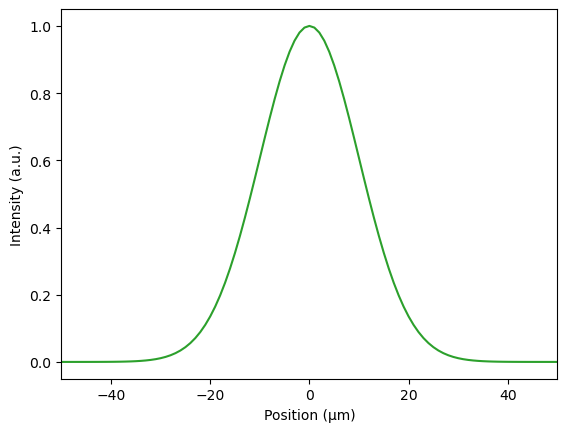

In [2]:
wavelength_m = 10e-9     # wavelength, m
dx_m = 1e-6               # grid spacing, m
L_m  = 20e-3                # screen size, m
x_m = np.linspace(-L_m/2, L_m/2, int(L_m/dx_m) + 1)


x_mean_m = 0 #center of gaussian
x_std_m = 10e-6 #width of gaussian
gauss = np.exp(-(x_m - x_mean_m)**2/(2*(x_std_m**2)))
E0 = np.sqrt(gauss) # field amplitude is sqrt of intensity
plt.plot(x_m*1e6, E0**2, color='tab:green')
plt.xlabel("Position (µm)")
plt.ylabel("Intensity (a.u.)") 
plt.xlim(-50, 50)
plt.show()


# Note this is the Gaussian function, not an actual distribution 

In [3]:
# # Normalisation factor (sum of the Gaussian samples)
norm = np.sum(E0**2)

# # First moment → mean
x_mean_est_m = np.sum(x_m * np.abs(E0)**2) / norm
#print(f"Estimated mean  = {x_mean_est_m:.5f} m (true = {x_mean_m})")

# # Second central moment → variance
x_std_est_m = np.sqrt(np.sum(((x_m - x_mean_est_m)**2) * np.abs(E0)**2) / norm)
print(f"Estimated = {(x_std_est_m*1e6):.5f} µm (true = {x_std_m*1e6:.5f} µm)")

Estimated = 10.00000 µm (true = 10.00000 µm)


## Propagate the beam
We propagate the beam using the Fresnel kernel in the Fourier domain. We propagate it to the locate of the first focusing element (~16.m)

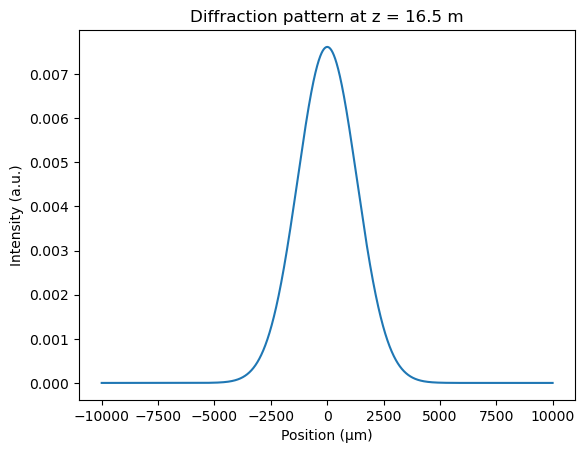

In [4]:
# locate of focusing element
z_m= 16.5

Em = propTF(E0, L_m, wavelength_m, z_m)
Im = np.abs(Em)**2
plt.plot(x_m*1e6, Im, color='tab:blue')
plt.xlabel("Position (µm)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"Diffraction pattern at z = {z_m} m")
plt.show()

In [5]:
# we can check that we are note introducing aliasing (needs to be < 1)
dx_m/(wavelength_m*z_m/L_m)

0.1212121212121212

## Focusing the beam
We focus the beam using the quadrativ phase of a lens function.
We expect the beam at focus to be the initial beam size times the demag (here: ~5times smaller so about 2 um-rms)

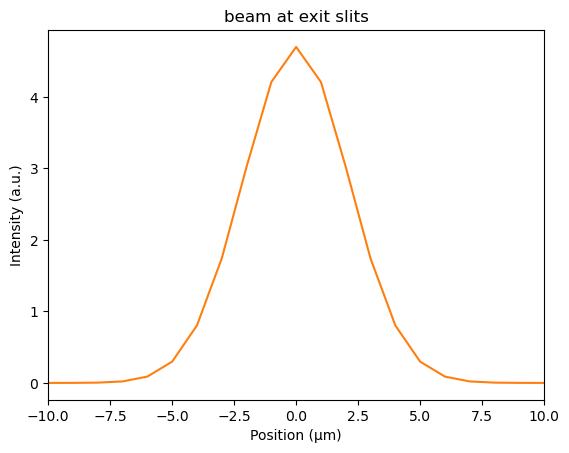

In [6]:
# object distance
p_m = z_m
# image distance
q_m = 3.5 

# focal length
f_m = 1/(1/(p_m) + (1/q_m)) #f_m = focal length, p_m = z_pm

# quadratic phase factor for thin lens
lens = np.exp(-1j*(2*np.pi/wavelength_m)/(2*f_m)*x_m**2)

El = Em*lens
Ef = propTF(El, L_m, wavelength_m, q_m)
If = np.abs(Ef)**2
plt.plot(x_m*1e6, If, color='tab:orange')
plt.xlabel("Position (µm)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"beam at exit slits")

plt.xlim(-10, 10)
plt.show()

In [7]:
# # Normalisation factor (sum of the Gaussian samples)
norm = np.sum(np.abs(Ef)**2)

# # First moment → mean
x_mean_est_m = np.sum(x_m * np.abs(Ef)**2) / norm
#print(f"Estimated mean  = {x_mean_est_m:.5f} m (true = {x_mean_m})")

# # Second central moment → variance
x_std_est_m = np.sqrt(np.sum(((x_m - x_mean_est_m)**2) * np.abs(Ef)**2) / norm)
print(f"Estimated beam size at focus= {(x_std_est_m*1e6):.5f} µm")

Estimated beam size at focus= 2.12838 µm


## Adding slits
We add slit tp the beam at focus, roughly at FWHM (so that the divergence is roughly that of a non-slitted gaussian beam), but with a longitudinal separation of the slits

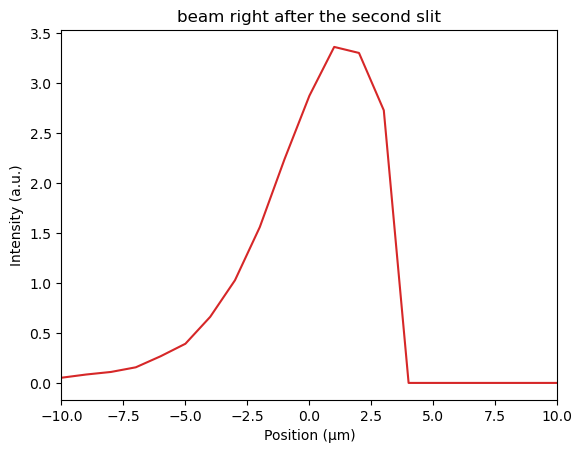

In [8]:
slit_size_m = 6e-6 # 2um *2.35 ~ FWHM of the beam at focus
zs_m = 4e-3

blade_up = np.where(x_m >= -slit_size_m/2 , 1,0)
blade_down = np.where(x_m <= slit_size_m/2 , 1,0)

Eslit_blade_up = Ef*blade_up
#Islit_blade_up = np.abs(Eslit_blade_up)**2
Eslit_blade_down = propTF(Eslit_blade_up, L_m, wavelength_m, zs_m)*blade_down

Islit_blade_down = np.abs(Eslit_blade_down)**2
plt.plot(x_m*1e6, Islit_blade_down, color='tab:red')
plt.xlabel("Position (µm)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"beam right after the second slit")
plt.xlim(-10, 10)
plt.show()



It looks as if the diffraction from the first slit had been already fully developped (no ripples.)
The fresnel distance  is zf = (slit size)^2/lambda = 3.6, consistent with our observation

the depth of focus for this case is sigma = sigma'z_dof -> z_dof = sigma/sigma'= sigma^2*4*pi/lamda = 5.5 mm (the slit spacing is lower than the dof)



## propagating the beam to the far field

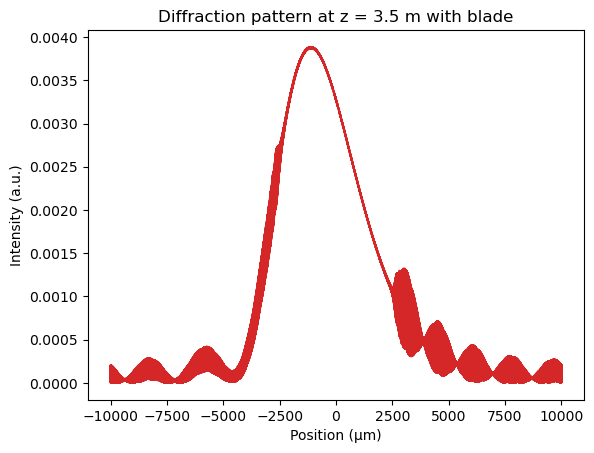

In [9]:
Eslit_blade_ff = propTF(Eslit_blade_down, L_m, wavelength_m, q_m)
Islit_blade_ff = np.abs(Eslit_blade_ff)**2
plt.plot(x_m*1e6, Islit_blade_ff, color='tab:red')
plt.xlabel("Position (µm)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"Diffraction pattern at z = {q_m} m with blade")
#plt.xlim(-10, 10)
plt.show()

The beam shows a slit asymetry in the far field, and what looks like numerical artifcats

## Refocusing

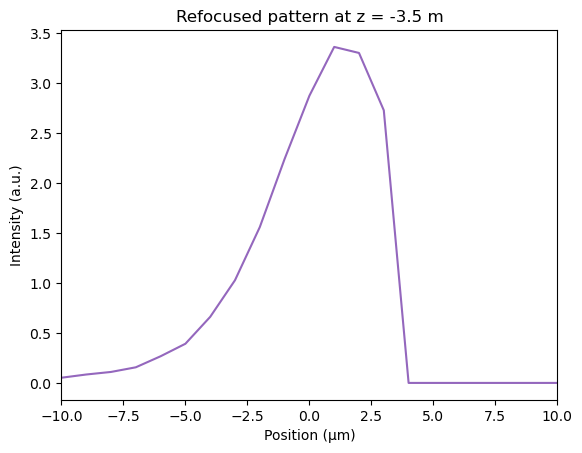

In [10]:
E_refocused = propTF(Eslit_blade_ff, L_m, wavelength_m, -q_m)
I_refocused = np.abs(E_refocused)**2
plt.plot(x_m*1e6, I_refocused, color='tab:purple')     
plt.xlabel("Position (µm)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"Refocused pattern at z = {-q_m} m")
plt.xlim(-10, 10)
plt.show()

## Looking at z-scans

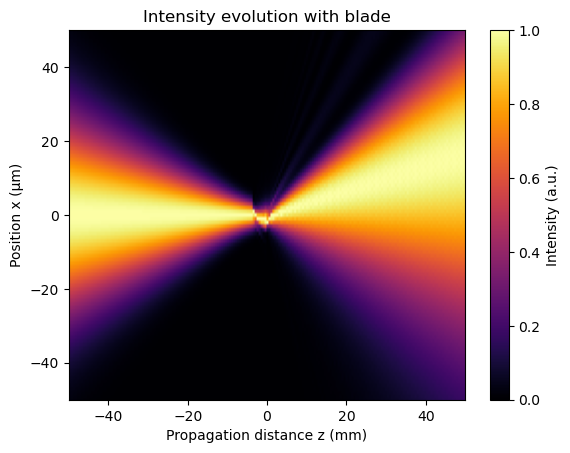

In [11]:
slit_size_m = 6e-6
blade_up = np.where(x_m >= -slit_size_m/2 , 1,0)
blade_down = np.where(x_m <= slit_size_m/2 , 1,0)

#distance between slits
zs_m = 4e-3

zscan = np.linspace(-50e-3, 50e-3, 201)
dz_m = zscan[1] - zscan[0]

Iz = np.zeros((E0.size, zscan.size))
Ez = propTF(Ef, L_m, wavelength_m, zscan[0])
for i_z in range(zscan.size):
    if zscan[i_z] < -zs_m:
        pass
    if (zscan[i_z] >= -zs_m) & (zscan[i_z]<-zs_m+dz_m):
        Ez = Ez*blade_up
    if (zscan[i_z] >= 0) & (zscan[i_z]<dz_m):
        Ez = Ez*blade_down
    if zscan[i_z] >=dz_m:
        pass
    Ez = propTF(Ez, L_m, wavelength_m, dz_m)
    Iz[:,i_z] = np.abs(Ez)**2
    Iz[:,i_z] = Iz[:,i_z]/Iz[:,i_z].max() # normalise to max intensity for better visualization

plt.imshow(Iz, extent=[zscan[0]*1e3, zscan[-1]*1e3, x_m[0]*1e6, x_m[-1]*1e6], aspect='auto', cmap='inferno')
plt.colorbar(label='Intensity (a.u.)')
plt.xlabel('Propagation distance z (mm)')
plt.ylabel('Position x (µm)')
plt.title('Intensity evolution with blade')
plt.ylim(-50, 50)
plt.xlim(-50, 50)
plt.show()


### close up

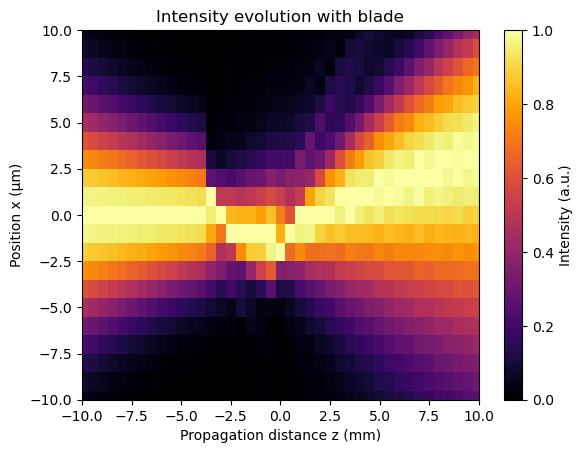

In [12]:
plt.imshow(Iz, extent=[zscan[0]*1e3, zscan[-1]*1e3, x_m[0]*1e6, x_m[-1]*1e6], aspect='auto', cmap='inferno')
plt.colorbar(label='Intensity (a.u.)')
plt.xlabel('Propagation distance z (mm)')
plt.ylabel('Position x (µm)')
plt.title('Intensity evolution with blade')
plt.ylim(-10, 10)
plt.xlim(-10, 10)
plt.show()

## drift to the zoneplate or KB
In practice, the beam will propagate to the next element that will have an aperture typically defined by the FWHM beam size at the element, or smaller (flooding.)

In [13]:
q3_m = 3.0 # distance of M3 from focus

mag = q_m/p_m
divergence_rad = wavelength_m/(4*np.pi*x_std_m)/mag
print(f"Estimated divergence = {(divergence_rad*1e6):.5f} µrad-rms")
Sigma_zp_m = divergence_rad*q3_m*6
print(f"Estimated beam size at z = {q_m} m = {(Sigma_zp_m*1e6):.5f} µm-rms")    

Estimated divergence = 375.15094 µrad-rms
Estimated beam size at z = 3.5 m = 6752.71687 µm-rms


In [14]:
#M213 and M214 are 300 mm long at 1.5m and 3.0m and 3.8m distance
M213_size_onaxis_m = 300e-3*np.sin(1.5*np.pi/180)
print(f"M213 size on axis = {(M213_size_onaxis_m*1e6):.5f} µm")

M213 size on axis = 7853.08449 µm


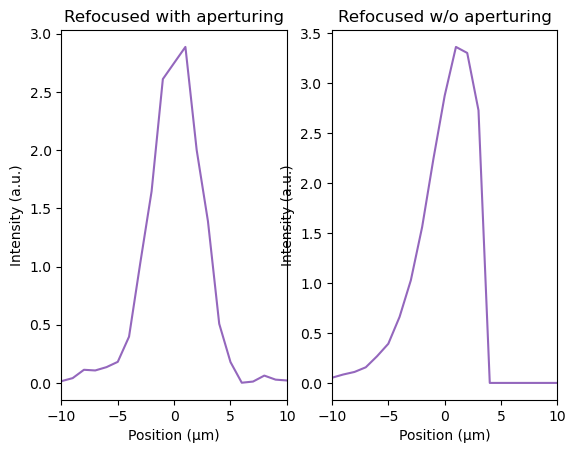

In [15]:
aperture = np.where(x_m <= Sigma_zp_m/2 , 1,0)*np.where(x_m >= -Sigma_zp_m/2 , 1,0)
E_aper_refocused = propTF(Eslit_blade_ff*aperture, L_m, wavelength_m, -q_m)
I_aper_refocused = np.abs(E_aper_refocused)**2

plt.subplot(1,2,1)
plt.plot(x_m*1e6, I_aper_refocused, color='tab:purple')     
plt.xlabel("Position (µm)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"Refocused with aperturing")
plt.xlim(-10, 10)

plt.subplot(1,2,2)
plt.plot(x_m*1e6, I_refocused, color='tab:purple')     
plt.xlabel("Position (µm)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"Refocused w/o aperturing")
plt.xlim(-10, 10)
plt.show()

We do observe the the beam with apeturing is indeed a bit larger, but doesn't show significant asymetry from the slits. In this case we used an aperture at FWHM (75% of the energy.) The information about the slit encoded in high frequencies that should in principle be filtered by the system

Et voila!